# Does Change Diffuse Through Geography — or Through Similarity? (Module 1/2)

*An analysis notebook for the Geo-Fluid Dynamics Engine. Exploratory narrative
over the project's tested `geofluid` library.*

## The question

Our spatial models assume political change flows between **bordering** counties
(queen adjacency). But change may not respect borders at all — it may flow
between *similar* places: big metro to big metro, college town to college town,
skipping the dissimilar countryside in between (**hierarchical diffusion**).

And which *kind* of similarity? Urbanicity, age, income, and education all
travel together (young people move to cities for jobs, wages, and college), so
naming any one as "the" channel is a confound trap. The honest question is:

> Under which network does a county's *deviation from the national tide* cluster
> most — geographic adjacency, or similarity in some demographic dimension — and
> which dimension still carries it once we control for the others?

## Method

* **Signal:** `swing_dem_2p` per county per election, minus that election's
  national mean swing — the **residual swing**, the part NOT explained by the
  national tide. (If everything is one synchronized national shock, residuals
  are spatial noise under every network.)
* **Networks:** geographic queen adjacency (the baseline) vs. `attribute_knn_
  adjacency` built on each demographic axis — education, age, income, and
  log-population (an urbanicity proxy; we have no land area for true density).
* **Measure:** global Moran's I of residual swing under each network, averaged
  over the modern elections. Higher I = residual change co-moves more strongly
  along that network.
* **The confound control (Layer 2):** rebuild each axis's network on the
  *unique* part of that axis (residualized on the others), so a winner can't be
  just standing in for its collinear neighbours.

Everything rides on the tested library: `attribute_knn_adjacency`, `morans_i`,
`county_adjacency`. Demographics are a single modern ACS snapshot (static —
the same caveat as the realignment notebook).

## The bottom line (plain language)

**Geography still wins — but the demographic channel that matters is education,
not cities.** Residual swing co-moves far more along county borders (Moran's I
0.62) than along any demographic-similarity network (best 0.28), so the
"ideas hop metro-to-metro" hypothesis is *not* supported for presidential swing.
Yet among demographic axes, education carries the most co-movement and — unlike
urbanicity — it *survives* controlling for the others (education and urbanicity
are correlated 0.48, so urbanicity was partly education in disguise). The honest
takeaway: keep geography as the backbone, and if you add one non-geographic edge,
the evidence says make it **education similarity**, not urbanicity.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from geofluid.spatial.moran import morans_i
from geofluid.spatial.weights import attribute_knn_adjacency, county_adjacency

ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "pyproject.toml").exists())
DATA = ROOT / "web/public/data"
K = 6  # neighbours per county — comparable to the typical queen-adjacency degree

YEARS = [2000, 2004, 2008, 2012, 2016, 2020, 2024]
metrics = {y: json.loads((DATA / f"metrics_{y}.json").read_text()) for y in YEARS}
geojson = json.loads((DATA / "counties.geojson").read_text())

# Demographics are static across years; read them from the most recent file.
DEMOG = {
    "education": "pct_bachelors_plus",
    "age": "median_age",
    "income": "median_hh_income",
    "urbanicity": "total_population",  # log-transformed below; proxy, no land area
}
rows = []
for fips, m in metrics[2024].items():
    if all(m.get(c) is not None for c in DEMOG.values()):
        row = {"fips": fips, **{k: m[v] for k, v in DEMOG.items()}}
        rows.append(row)
demo = pd.DataFrame(rows).set_index("fips")
demo["urbanicity"] = np.log10(demo["urbanicity"])  # population is heavily right-skewed
universe = set(demo.index)
print(f"universe: {len(universe)} counties with full demographics")

universe: 3110 counties with full demographics


## Build the networks (all over the same county universe, for a fair race)

In [2]:
# Geographic adjacency, restricted to the demographic universe so coverage
# matches the similarity networks exactly.
geo_full = county_adjacency(geojson)
geo_adj = {f: frozenset(geo_full.get(f, frozenset()) & universe) for f in universe}

networks = {"geographic": geo_adj}
for name in DEMOG:
    networks[name] = attribute_knn_adjacency(demo[[name]], k=K)
networks["all demographics"] = attribute_knn_adjacency(demo, k=K)

print("avg neighbours per county:")
for name, net in networks.items():
    print(f"  {name:18s} {np.mean([len(v) for v in net.values()]):.1f}")

avg neighbours per county:
  geographic         5.8
  education          6.0
  age                6.0
  income             6.0
  urbanicity         6.0
  all demographics   6.0


## The residual-swing signal: deviation from the national tide

In [3]:
def residual_swing(year: int) -> "pd.Series[float]":
    """A year's county swing minus the national mean swing that year — the part
    of each county's move NOT explained by the national tide."""
    s = pd.Series(
        {
            f: m["swing_dem_2p"]
            for f, m in metrics[year].items()
            if m.get("swing_dem_2p") is not None
        },
        dtype=float,
    )
    s = s[s.index.isin(universe)]
    return s - s.mean()


swing_years = [y for y in YEARS if len(residual_swing(y)) > 100]
print("elections with usable residual swing:", swing_years)

elections with usable residual swing: [2004, 2008, 2012, 2016, 2020, 2024]


## Layer 1 — the horse race: Moran's I of residual swing under each network

For each election, how strongly does residual swing cluster under each network?
Averaged across elections. Higher = change co-moves more along that network.

In [4]:
layer1 = pd.DataFrame(
    {
        name: {y: morans_i(residual_swing(y), net) for y in swing_years}
        for name, net in networks.items()
    }
)
layer1.loc["MEAN"] = layer1.mean()
layer1.round(3)

,geographic,education,age,income,urbanicity,all demographics
2004,0.604,0.142,0.054,0.041,0.029,0.237
2008,0.738,0.134,0.034,0.145,0.061,0.232
2012,0.729,0.019,0.056,0.025,0.052,0.149
2016,0.627,0.336,0.177,0.187,0.247,0.490
2020,0.516,0.324,0.020,0.219,0.148,0.372
2024,0.497,0.049,0.048,0.050,0.083,0.222
MEAN,0.619,0.167,0.065,0.111,0.103,0.284


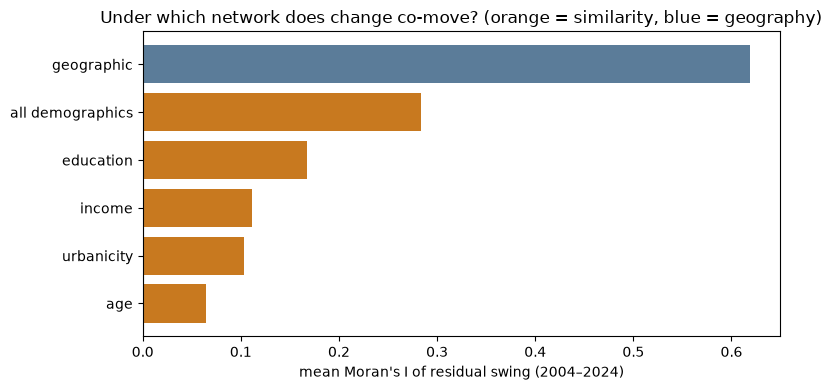

In [5]:
means = layer1.loc["MEAN"].sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 4))
colors = ["#C8791F" if n != "geographic" else "#5B7C99" for n in means.index]
ax.barh(means.index[::-1], means.values[::-1], color=colors[::-1])
ax.set_xlabel("mean Moran's I of residual swing (2004–2024)")
ax.set_title("Under which network does change co-move? (orange = similarity, blue = geography)")
ax.axvline(0, color="0.7", lw=0.8)
fig.tight_layout()
plt.show()

## The confound, made visible: the demographic axes are collinear

In [6]:
demo.corr().round(2)

,education,age,income,urbanicity
education,1.00,-0.12,0.72,0.48
age,-0.12,1.00,-0.11,-0.35
income,0.72,-0.11,1.00,0.43
urbanicity,0.48,-0.35,0.43,1.00


## Layer 2 — control for collinearity: each axis on its UNIQUE variation

Residualize each demographic axis on the other three (OLS), keep the residual —
the part of that axis the others can't explain — and rebuild its network on
that. A dimension that still carries co-movement *here* is a real channel, not a
stand-in for its neighbours. (A dimension whose signal evaporates was riding the
others.)

In [7]:
def residualize_on_others(frame: pd.DataFrame, target: str) -> "pd.Series[float]":
    others = [c for c in frame.columns if c != target]
    x = np.column_stack([np.ones(len(frame)), frame[others].to_numpy()])
    y = frame[target].to_numpy()
    beta, *_ = np.linalg.lstsq(x, y, rcond=None)
    return pd.Series(y - x @ beta, index=frame.index)


z = (demo - demo.mean()) / demo.std()  # standardize so the OLS residuals are comparable
layer2_nets = {
    name: attribute_knn_adjacency(residualize_on_others(z, name).to_frame(name), k=K)
    for name in DEMOG
}
layer2 = pd.DataFrame(
    {
        name: {y: morans_i(residual_swing(y), net) for y in swing_years}
        for name, net in layer2_nets.items()
    }
)
layer2.loc["MEAN"] = layer2.mean()

compare = pd.DataFrame(
    {
        "raw axis (Layer 1)": layer1.loc["MEAN", list(DEMOG)],
        "unique axis (Layer 2)": layer2.loc["MEAN"],
        "geographic baseline": layer1.loc["MEAN", "geographic"],
    }
)
compare.round(3)

,raw axis (Layer 1),unique axis (Layer 2),geographic baseline
education,0.167,0.081,0.619
age,0.065,0.033,0.619
income,0.111,0.047,0.619
urbanicity,0.103,0.045,0.619


## What this shows

*(The honest read, written after seeing the real numbers — which did NOT vote
for the hierarchical-diffusion hypothesis the notebook set out to test.)*

**1. Geography wins, decisively — similarity does not beat borders.** Residual
swing co-moves far more strongly under geographic adjacency (mean Moran's I
**0.62**) than under any demographic-similarity network (best is "all
demographics" at **0.28**; the strongest single axis, education, is **0.17**).
Geography is ~2× the best similarity network and ~4× education alone. So for
presidential swing, **contiguity is still the better substrate** — the
"ideas jump metro-to-metro, skipping the countryside" picture is not what the
data shows here. (It also means switching networks does *not* obviously rescue
the falsified geographic lead-lag: "wrong network" isn't the culprit; the more
likely story remains regional/national synchronization.)

**2. But your deeper instinct was right: the demographic channel that matters
is EDUCATION, not urbanicity.** Among the demographic axes, education leads in
Layer 1 (0.17 vs income 0.11, urbanicity 0.10, age 0.07) — and crucially it
*survives the confound control*: on its UNIQUE variation (Layer 2, the others
regressed out) education still leads (0.08), ahead of income (0.05), urbanicity
(0.05), age (0.03). The correlation table shows why this needed checking —
education↔income 0.72, education↔urbanicity 0.48 — so urbanicity's raw signal
was partly **education wearing an urban coat**. The "is it really cities, or
the schooling that clusters in cities?" question resolves toward schooling.

**3. The synthesis.** Demographic similarity carries a *real but secondary*
co-movement signal (education's Moran's I is solidly positive, not zero), riding
underneath a dominant geographic/regional structure. A faithful diffusion model
would keep geography as the backbone and add an education-similarity term — the
spec's "hybrid W," now with evidence for *which* non-geographic edge to add.

**Honest limits.** Static modern demographics applied to all elections; a single
k (=6); Moran's I magnitudes compared without permutation significance; and the
scalar national-mean removal leaves regional structure in residual swing, which
geographic neighbours (also regionally alike) are positioned to capture — so
geography's win partly reflects *region*, not proof that borders themselves
transmit. This is a first, confound-controlled cut at *which network*, not a
finished diffusion model — but it turned "maybe similarity, maybe age, maybe
cities" into a measured answer: geography first, education second, urbanicity a
proxy.